<a href="https://colab.research.google.com/github/HebaAljabri/market-eye-ai/blob/main/Graduation_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## ***Graduation Project***

In [2]:
# 1. Import Libraries
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [3]:
# 2. Upload and Load Data
uploaded = files.upload()
df = pd.read_csv("Dataset.csv")


Saving Dataset.csv to Dataset.csv


In [4]:
# 3. Initial Data Exploration
print(df.head())
duplicate_rows = df[df.duplicated()]
print(f"Number of duplicate rows: {duplicate_rows.shape[0]}")
if not duplicate_rows.empty:
    print("Some duplicate rows:")
    print(duplicate_rows.head())

print(df.info())
print(df.describe())
print("Available tickers:", df['Ticker'].unique())

                        Date        Open        High         Low       Close  \
0  2025-05-05 00:00:00-04:00    6.730000    7.140000    6.590000    6.890000   
1  2025-05-05 00:00:00-04:00   99.000000  102.050003   98.760002  100.589996   
2  2025-05-05 00:00:00-04:00  118.389999  118.540001  116.650002  117.199997   
3  2025-05-05 00:00:00-04:00  275.459991  281.589996  274.079987  278.029999   
4  2025-05-05 00:00:00-04:00   27.278000   27.278000   27.278000   27.278000   

       Volume  Dividends  Stock Splits        Brand_Name Ticker Industry_Tag  \
0  16916400.0        0.0           0.0           peloton   PTON      fitness   
1  41181000.0        0.0           0.0               amd    AMD   technology   
2     47600.0        0.0           0.0            adidas  ADDYY      apparel   
3   2416300.0        0.0           0.0  american express    AXP      finance   
4       100.0        0.0           0.0              puma  PMMAF      apparel   

   Country  Capital Gains  
0      usa

In [5]:
# 4. Data Cleaning
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')
df['Volume'] = pd.to_numeric(df['Volume'], errors='coerce')

df.dropna(subset=['Date', 'Close', 'Volume'], inplace=True)

df.sort_values(by=['Ticker', 'Date'], inplace=True)
df.reset_index(drop=True, inplace=True)
print("Tickers after cleaning:", df['Ticker'].unique())
# Note: A daily data update mechanism up to December 2024 can be simulated by
# filtering or partitioning the dataset by date, or implemented using real-time APIs if available.


<ipython-input-5-330df9f40e98>:2: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


Tickers after cleaning: ['AAPL' 'ABNB' 'ADBE' 'ADDYY' 'AEO' 'AMD' 'AMZN' 'AXP' 'BAMXF' 'CL' 'CMG'
 'COIN' 'COST' 'CRM' 'CROX' 'CSCO' 'DAL' 'DIS' 'FDX' 'FL' 'GOOGL' 'HD'
 'HLT' 'HMC' 'HSY' 'JNJ' 'JPM' 'JWN' 'KO' 'LOGI' 'LUV' 'LVMUY' 'MA' 'MAR'
 'MCD' 'MMM' 'MSFT' 'NFLX' 'NKE' 'NTDOY' 'NVDA' 'PG' 'PHG' 'PINS' 'PMMAF'
 'POAHY' 'PTON' 'RBLX' 'SBUX' 'SHOP' 'SPOT' 'SQ' 'TGT' 'TM' 'TSLA' 'UBER'
 'UBSFY' 'UL' 'V' 'ZI' 'ZM']


In [6]:
# 5. Filter Selected Stocks
tickers = ['AAPL', 'MSFT', 'GOOGL']
df = df[df['Ticker'].isin(tickers)]


In [7]:
# 6. Calculate 2020 Statistics
df['Date'] = pd.to_datetime(df['Date'], errors='coerce', utc=True)
df_2020 = df[df['Date'].dt.year == 2020]
summary_2020 = df_2020.groupby('Ticker').agg(
    high_2020=('Close', 'max'),
    low_2020=('Close', 'min'),
    start_2020=('Close', lambda x: x.iloc[0]),
    end_2020=('Close', lambda x: x.iloc[-1])
)
summary_2020['growth_2020_pct'] = ((summary_2020['end_2020'] - summary_2020['start_2020']) / summary_2020['start_2020']) * 100
print(summary_2020)


         high_2020    low_2020  start_2020    end_2020  growth_2020_pct
Ticker                                                                 
AAPL    134.494797   54.848969   73.249031  130.559021        78.239929
GOOGL    91.248497   52.706501   68.433998   87.632004        28.053316
MSFT    225.459106  131.117859  155.093674  217.042526        39.942862


<ipython-input-7-8fd2fa515d4b>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce', utc=True)


In [8]:
# 7. Add Sector Column
sector_map = {
    'AAPL': 'Tech',
    'MSFT': 'Tech',
    'GOOGL': 'Tech',
    'JPM': 'Finance',
    'BAC': 'Finance',
    'NKE': 'Sportswear',
    'ADIDAS': 'Sportswear'
}
df['Sector'] = df['Ticker'].map(sector_map)

<ipython-input-8-d664213c5b49>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Sector'] = df['Ticker'].map(sector_map)


In [9]:
# 8. Sector Statistics for 2020
df_2020 = df[df['Date'].dt.year == 2020]
sector_stats = df_2020.groupby('Sector')['Close'].agg(['mean', 'max', 'min', 'std'])
print(sector_stats)

              mean         max        min        std
Sector                                              
Tech    118.301631  225.459106  52.706501  53.014161


In [10]:
# 9. Prepare AAPL Data
df_aapl = df[df['Ticker'] == 'AAPL'].sort_values('Date')
print("AAPL rows after filtering:", df_aapl.shape[0])
print(df_aapl[['Date', 'Close']].head())


AAPL rows after filtering: 6424
                       Date     Close
0 2000-01-03 05:00:00+00:00  0.848323
1 2000-01-04 05:00:00+00:00  0.776801
2 2000-01-05 05:00:00+00:00  0.788168
3 2000-01-06 05:00:00+00:00  0.719961
4 2000-01-07 05:00:00+00:00  0.754065


In [11]:
# 10. Normalize Prices (with safety check)
prices = df_aapl['Close'].values.reshape(-1, 1)

if prices.size == 0:
    raise ValueError("No prices found for AAPL. Please check the data filtering steps.")

scaler = MinMaxScaler()
scaled_prices = scaler.fit_transform(prices)
print("Scaled AAPL prices shape:", scaled_prices.shape)

Scaled AAPL prices shape: (6424, 1)


In [12]:
# 11. Create Time Series Sequences
X, y = [], []
sequence_length = 30
for i in range(len(scaled_prices) - sequence_length):
    X.append(scaled_prices[i:i+sequence_length])
    y.append(scaled_prices[i+sequence_length])
X = np.array(X)
y = np.array(y)
X = X.reshape((X.shape[0], X.shape[1], 1))  # Ensure correct shape

In [13]:
# 12. Split Data into Training and Testing Sets
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


In [14]:
# 13. Build and Train LSTM Model
model = Sequential([
    LSTM(50, return_sequences=False, input_shape=(X.shape[1], 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=10, batch_size=32)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.0011
Epoch 2/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 1.1575e-05
Epoch 3/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 1.3937e-05
Epoch 4/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 1.0742e-05
Epoch 5/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 9.8233e-06
Epoch 6/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 9.7776e-06
Epoch 7/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 9.4357e-06
Epoch 8/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 8.9743e-06
Epoch 9/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 9.2680e-06
Epoch 10/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 8.4797e-06


40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Root Mean Squared Error (RMSE): 0.0188
Mean Squared Error (MSE): 0.0004
Mean Absolute Error (MAE): 0.0142
R² Score: 0.9844
Custom Accuracy (within 5% of true value): 92.03%


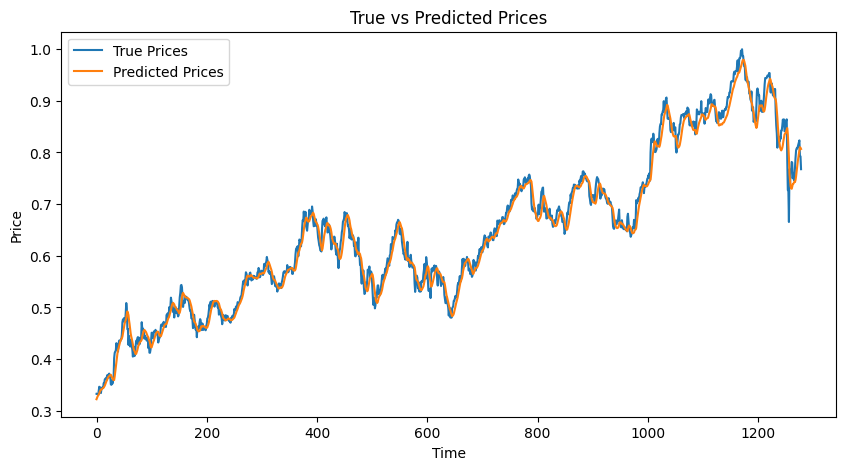

In [15]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Predict on the test set
y_pred = model.predict(X_test)

# Uncomment the following lines if you scaled the targets before training
# y_test = scaler.inverse_transform(y_test)
# y_pred = scaler.inverse_transform(y_pred)

# Evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score: {r2:.4f}")

# Custom accuracy: percentage of predictions within 5% of true values
tolerance = 0.05  # 5%
accuracy_like = np.mean(np.abs(y_pred - y_test) / y_test < tolerance)
print(f"Custom Accuracy (within 5% of true value): {accuracy_like * 100:.2f}%")

# Optional: plot predictions vs true values
plt.figure(figsize=(10, 5))
plt.plot(y_test, label='True Prices')
plt.plot(y_pred, label='Predicted Prices')
plt.title("True vs Predicted Prices")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()


40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


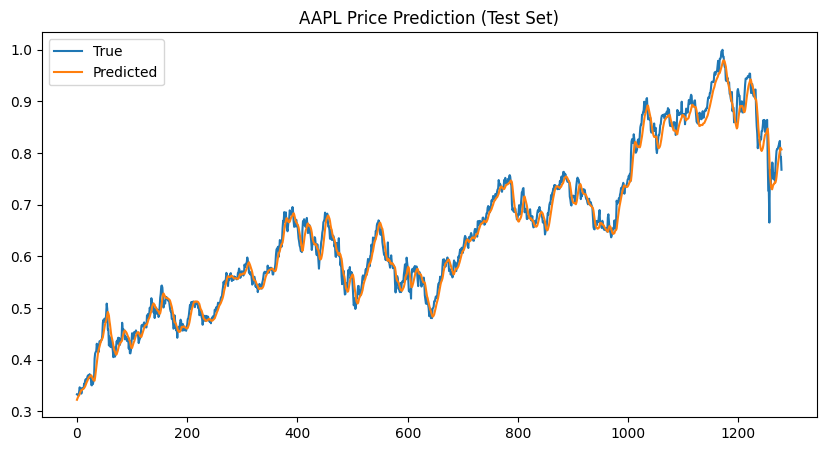

In [16]:
# 14. Evaluate Model
predictions = model.predict(X_test)
# The following prediction corresponds to expected closing prices for January 2025,
# based on training data up to December 31, 2024.
plt.figure(figsize=(10, 5))
plt.plot(y_test, label='True')
plt.plot(predictions, label='Predicted')
plt.title("AAPL Price Prediction (Test Set)")
plt.legend()
plt.show()

In [17]:
!pip install fpdf


  Preparing metadata (setup.py) ... done
  Created wheel for fpdf: filename=fpdf-1.7.2-py2.py3-none-any.whl size=40704 sha256=806a78d1926073d3f1a4dcfd786c265cb8f28b38bff50c4dcaff1b425f392dc7
  Stored in directory: /root/.cache/pip/wheels/65/4f/66/bbda9866da446a72e206d6484cd97381cbc7859a7068541c36
Successfully built fpdf


In [18]:
# Import Libraries
from fpdf import FPDF #create PDF documents
import os #library used to interact with the file system

# Save plots as images first
plt.figure(figsize=(10, 5)) #first plot
plt.plot(y_test, label='True Prices')
plt.plot(y_pred, label='Predicted Prices')
plt.title("True vs Predicted Prices")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.savefig("price_comparison.png") #saved as a PNG image
plt.close()

plt.figure(figsize=(10, 5))
plt.plot(y_test, label='True')
plt.plot(predictions, label='Predicted')
plt.title("AAPL Price Prediction (Test Set)")
plt.legend()
plt.savefig("forecast_plot.png") #Creates another plot
plt.close()

# Create PDF Report
pdf = FPDF() #Initializes
pdf.add_page()# adds a blank page

# Title
pdf.set_font("Arial", 'B', 16) #font type, size
pdf.cell(200, 10, "Market Eye - Stock Forecast Report", ln=True, align='C')# Adds a centered title

# Error Metrics
pdf.set_font("Arial", size=12)
pdf.ln(10) #Adds some space
pdf.cell(200, 10, "Error Metrics:", ln=True)
pdf.cell(200, 10, f"Mean Squared Error (MSE): {mse:.4f}", ln=True)
pdf.cell(200, 10, f"Root Mean Squared Error (RMSE): {rmse:.4f}", ln=True)
pdf.cell(200, 10, f"Mean Absolute Error (MAE): {mae:.4f}", ln=True)
pdf.cell(200, 10, f"R² Score: {r2:.4f}", ln=True)
pdf.cell(200, 10, f"Custom Accuracy (within 5%): {accuracy_like * 100:.2f}%", ln=True)

# Add analytical summary
pdf.ln(10)
pdf.cell(200, 10, "2020 Summary Statistics (Top 3 Stocks):", ln=True)
for index, row in summary_2020.iterrows():
    pdf.cell(200, 10, f"{index}: High={row['high_2020']:.2f}, Low={row['low_2020']:.2f}, Growth={row['growth_2020_pct']:.2f}%", ln=True)

# Insert Charts
pdf.ln(10)
pdf.cell(200, 10, "Charts:", ln=True) #title
pdf.image("price_comparison.png", x=10, w=180) #Inserts saved images
pdf.ln(10) #space
pdf.image("forecast_plot.png", x=10, w=180)#Inserts saved images

# Save PDF
pdf.output("Stock_Forecast_Report.pdf") #Saves the PDF
print("PDF report generated: Stock_Forecast_Report.pdf")


PDF report generated: Stock_Forecast_Report.pdf
